Imports

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

TensorFlow version: 2.19.0
Keras version: 3.13.2


Extract Dataset

In [ ]:
import zipfile

# Extract the uploaded zip file
with zipfile.ZipFile("Copy of devnagari digit.zip", "r") as z:
    z.extractall(".")

# Check extracted contents
for item in sorted(os.listdir(".")):
    print(item)

.config
Copy of devnagari digit.zip
DevanagariHandwrittenDigitDataset
sample_data


Task 1: Data Preparation

Classes found in 'DevanagariHandwrittenDigitDataset/Train/':
{'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Classes found in 'DevanagariHandwrittenDigitDataset/Test/':
{'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}

x_train : (17000, 784),  y_train : (17000, 10)
x_test  : (3000, 784),   y_test  : (3000, 10)


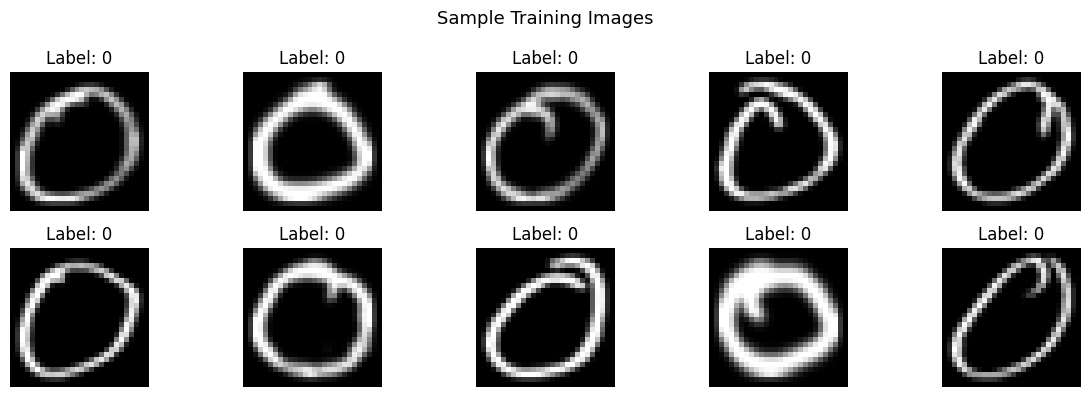

In [ ]:
train_dir = "DevanagariHandwrittenDigitDataset/Train/"
test_dir  = "DevanagariHandwrittenDigitDataset/Test/"

IMG_HEIGHT, IMG_WIDTH = 28, 28
NUM_CLASSES = 10

def load_images_from_folder(folder):
    images      = []
    labels      = []
    class_names = sorted(os.listdir(folder))
    class_map   = {name: idx for idx, name in enumerate(class_names)}
    print(f"Classes found in '{folder}':")
    print(class_map)

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")          # grayscale
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))         # 28x28
                img = np.array(img, dtype=np.float32) / 255.0    # normalise [0,1]
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"  Skipping {img_path}: {e}")

    return np.array(images), np.array(labels)


# Load raw images
x_train_raw, y_train_raw = load_images_from_folder(train_dir)
x_test_raw,  y_test_raw  = load_images_from_folder(test_dir)

# Flatten: (N, 28, 28) → (N, 784)
x_train = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)
x_test  = x_test_raw.reshape(-1,  IMG_HEIGHT * IMG_WIDTH)

# One-hot encode labels
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

# Verify shapes
print(f"\nx_train : {x_train.shape},  y_train : {y_train.shape}")
print(f"x_test  : {x_test.shape},   y_test  : {y_test.shape}")

# Visualise sample images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_raw[i], cmap="gray")
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=13)
plt.tight_layout()
plt.show()

Task 2: Build the FCN Model

In [ ]:
model = keras.Sequential(
    [
        keras.layers.Input(shape=(IMG_HEIGHT * IMG_WIDTH,)),

        # Hidden Layer 1
        keras.layers.Dense(64,  activation="sigmoid", name="hidden_1"),

        # Hidden Layer 2
        keras.layers.Dense(128, activation="sigmoid", name="hidden_2"),

        # Hidden Layer 3
        keras.layers.Dense(256, activation="sigmoid", name="hidden_3"),

        # Output Layer — 10 classes, softmax for probabilities
        keras.layers.Dense(NUM_CLASSES, activation="softmax", name="output"),
    ],
    name="FCN_Devnagari"
)

model.summary()

Model: "FCN_Devnagari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Task 3:Compile the Model

In [ ]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled!")
print("  Optimizer : Adam")
print("  Loss      : Categorical Cross-Entropy")
print("  Metric    : Accuracy")

Model compiled!
  Optimizer : Adam
  Loss      : Categorical Cross-Entropy
  Metric    : Accuracy


Task 4: Train the Model

In [ ]:
BATCH_SIZE = 128
EPOCHS     = 20

callbacks = [
    # Save the best model based on validation loss
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    # Stop early if val_loss doesn't improve for 5 epochs
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
]

history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2888 - loss: 1.9520
Epoch 1: val_loss improved from None to 6.95729, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.4922 - loss: 1.5780 - val_accuracy: 0.0000e+00 - val_loss: 6.9573
Epoch 2/20
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8245 - loss: 0.5926
Epoch 2: val_loss did not improve from 6.95729
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8592 - loss: 0.4721 - val_accuracy: 0.0000e+00 - val_loss: 8.4942
Epoch 3/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9194 - loss: 0.2872
Epoch 3: val_loss did not improve from 6.95729
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9245 - loss: 0.2675 - val_accuracy: 0.0000e+00 - val_loss: 9.1119
Epoch 4/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9446 - loss: 0.2031
Epoch 4: val_loss did not improve from 6.95729
107/107 ━━━━━━━━

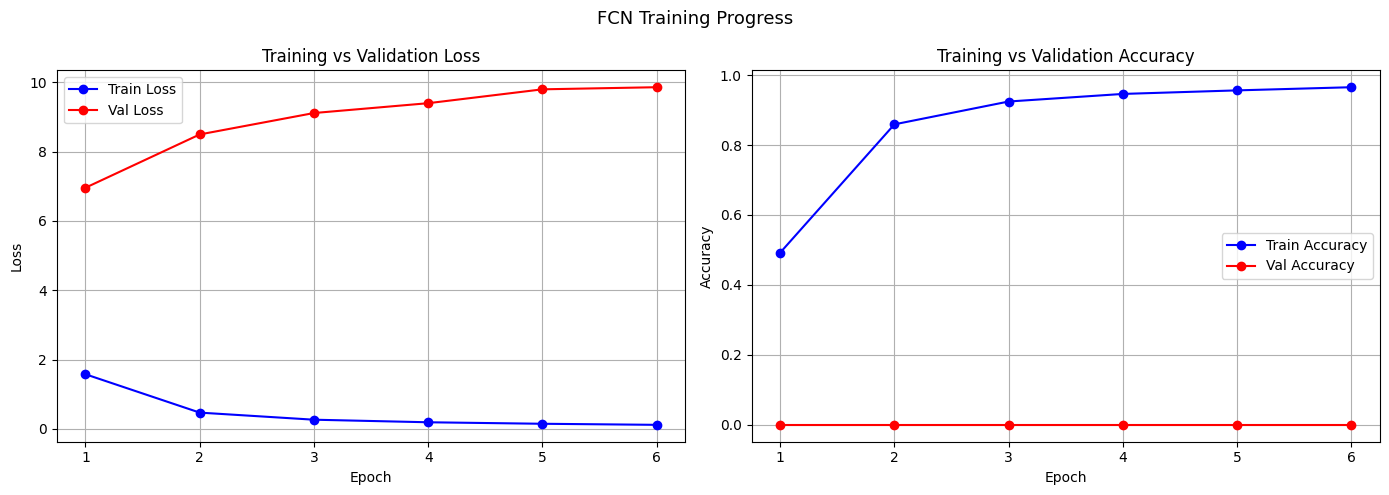

In [ ]:
# Plot Training Curves
train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]
train_acc  = history.history["accuracy"]
val_acc    = history.history["val_accuracy"]
epochs_ran = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_ran, train_loss, "b-o", label="Train Loss")
plt.plot(epochs_ran, val_loss,   "r-o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_ran, train_acc, "b-o", label="Train Accuracy")
plt.plot(epochs_ran, val_acc,   "r-o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.suptitle("FCN Training Progress", fontsize=13)
plt.tight_layout()
plt.show()

Task 5: Evaluate the Model

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"\n{'='*40}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc * 100:.2f}%")
print(f"{'='*40}")

94/94 - 0s - 3ms/step - accuracy: 0.6370 - loss: 1.9948

  Test Loss     : 1.9948
  Test Accuracy : 63.70%


Task 6: Save and Load the Model

In [ ]:
# Save
model.save("devnagari_fcn_model.h5")
print("Model saved as 'devnagari_fcn_model.h5'")

# Load
loaded_model = tf.keras.models.load_model("devnagari_fcn_model.h5")
print("Model loaded successfully!")

# Re-evaluate loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"\nLoaded Model — Test Accuracy: {loaded_acc * 100:.2f}%")

Model saved as 'devnagari_fcn_model.h5'
Model loaded successfully!
94/94 - 1s - 6ms/step - accuracy: 0.6370 - loss: 1.9948

Loaded Model — Test Accuracy: 63.70%


Task 7: Make Predictions

Index     Predicted     True   Correct?
----------------------------------------
0                 0        0          ✓
1                 0        0          ✓
2                 0        0          ✓
3                 0        0          ✓
4                 0        0          ✓
5                 0        0          ✓
6                 0        0          ✓
7                 0        0          ✓
8                 0        0          ✓
9                 0        0          ✓


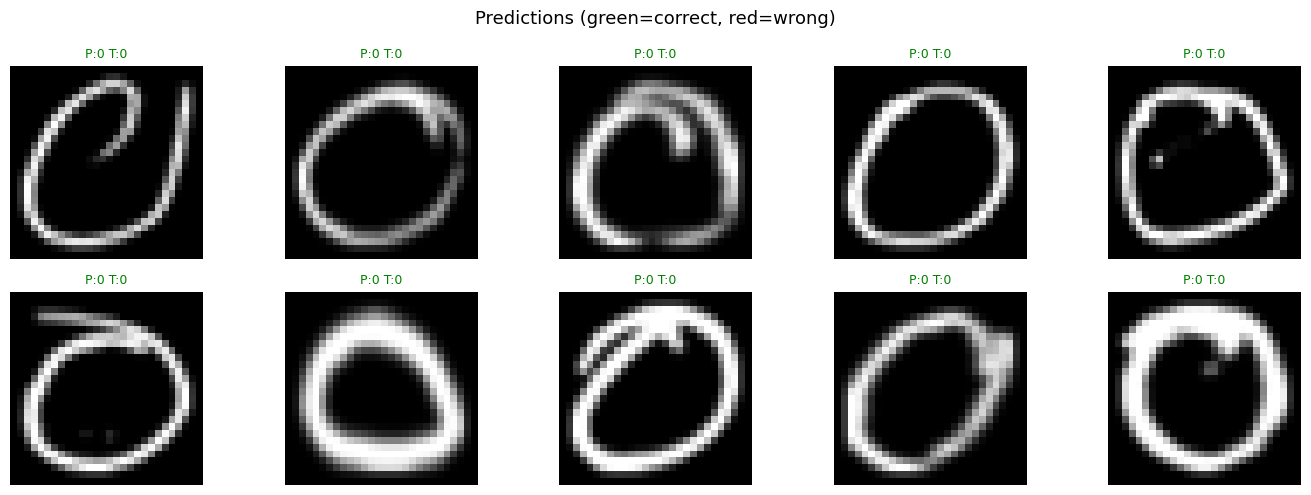

In [ ]:
# Get predictions
predictions      = loaded_model.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test, axis=1)

# Print sample results
print(f"{'Index':<8} {'Predicted':>10} {'True':>8} {'Correct?':>10}")
print("-" * 40)
for i in range(10):
    tick = "✓" if predicted_labels[i] == true_labels[i] else "✗"
    print(f"{i:<8} {predicted_labels[i]:>10} {true_labels[i]:>8} {tick:>10}")

# Visualise predictions
plt.figure(figsize=(14, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_raw[i], cmap="gray")
    pred  = predicted_labels[i]
    truth = true_labels[i]
    color = "green" if pred == truth else "red"
    plt.title(f"P:{pred} T:{truth}", color=color, fontsize=9)
    plt.axis("off")
plt.suptitle("Predictions (green=correct, red=wrong)", fontsize=13)
plt.tight_layout()
plt.show()